PCA result shape: (30, 3)
First few rows:
     Symbol       PC1       PC2
0   ADA-USD -4.092774 -0.147094
1  ATOM-USD -4.086704 -0.145341
2  AVAX-USD -4.059006 -0.138537
3   BCH-USD -3.591744 -0.066519
4  BETH-USD -0.530998  0.885562


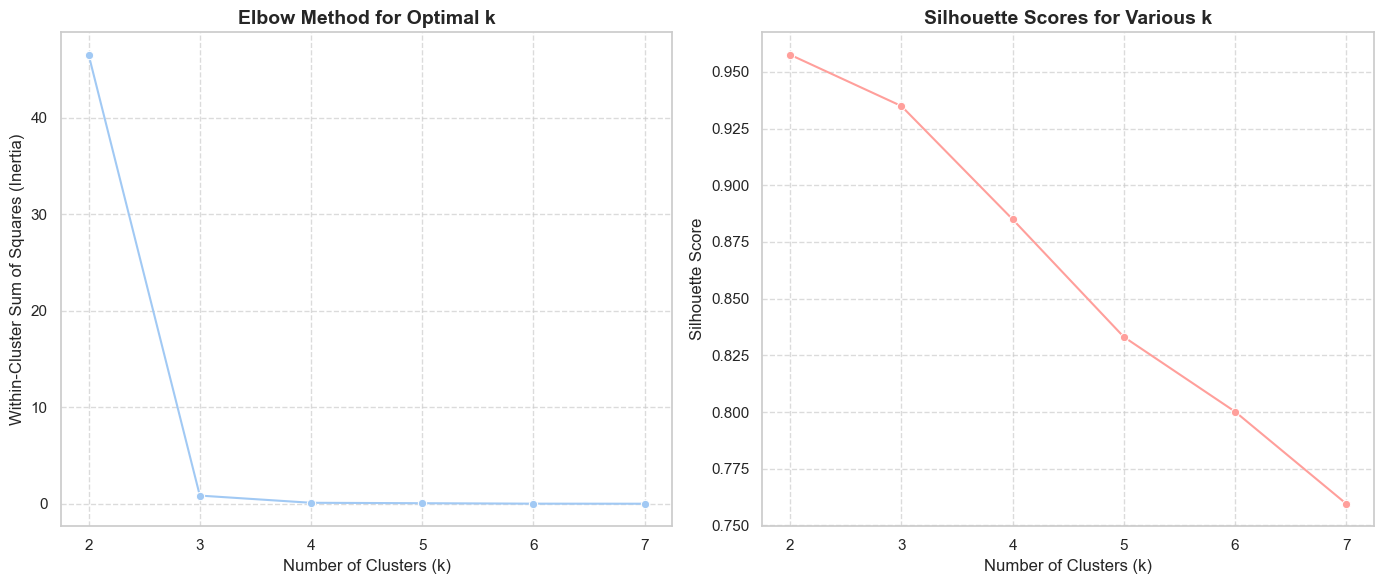


Cluster assignment of cryptocurrencies:
       Symbol  Cluster
0    WETH-USD        0
1    BETH-USD        0
2   STETH-USD        0
3     ETH-USD        0
4     BTC-USD        1
5     ADA-USD        2
6     TRX-USD        2
7     SUN-USD        2
8     SOL-USD        2
9    RUNE-USD        2
10   ONDO-USD        2
11   NEAR-USD        2
12    LTC-USD        2
13   LINK-USD        2
14    LEO-USD        2
15    KAS-USD        2
16   HBAR-USD        2
17    XLM-USD        2
18     GT-USD        2
19    FTN-USD        2
20    ETC-USD        2
21    DOT-USD        2
22   DOGE-USD        2
23    DAI-USD        2
24   AVAX-USD        2
25   ATOM-USD        2
26    ICP-USD        2
27    XRP-USD        2
28    BNB-USD        3
29    BCH-USD        3


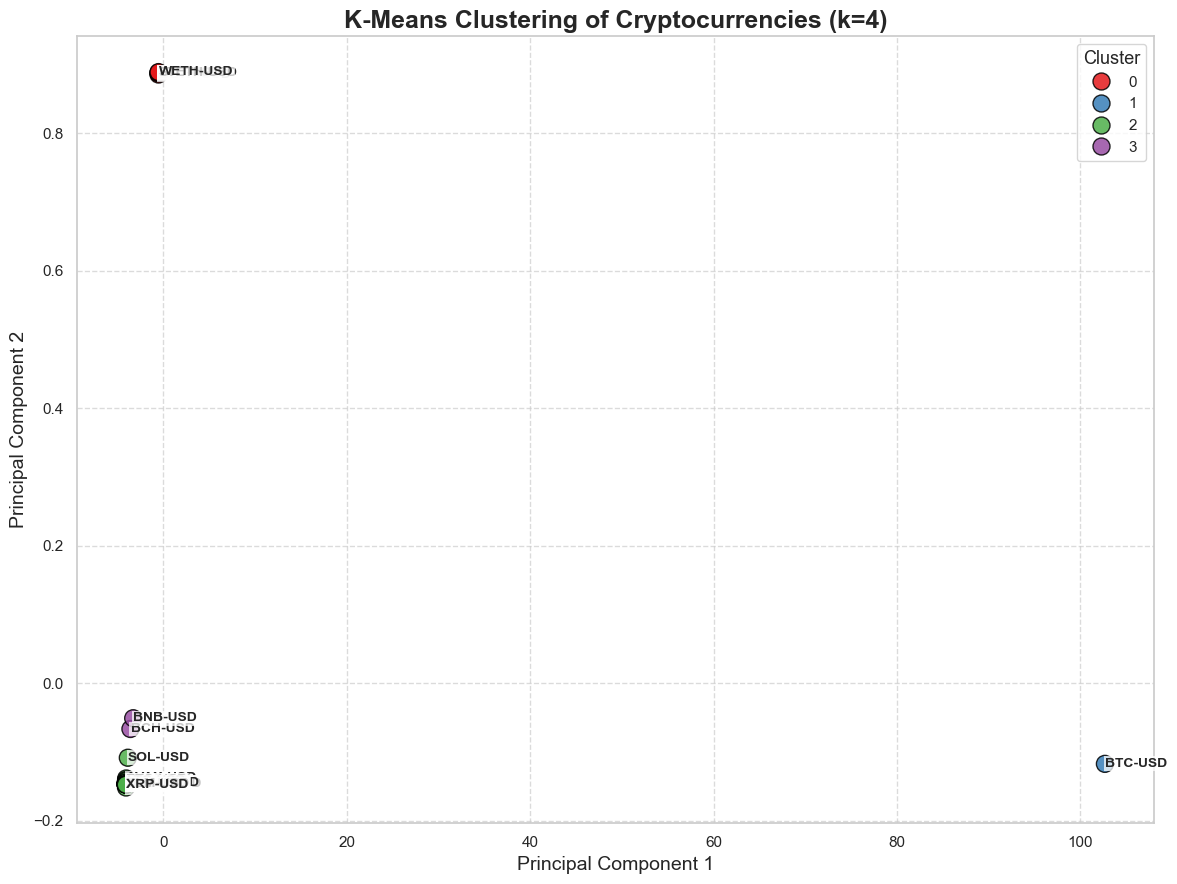


Data coverage for coins:
       Symbol  Cluster  StartDate    EndDate  \
0    BETH-USD        0 2024-07-01 2025-06-30   
1     ETH-USD        0 2024-07-01 2025-06-30   
2   STETH-USD        0 2024-07-01 2025-06-30   
3    WETH-USD        0 2024-07-01 2025-06-30   
4     BTC-USD        1 2024-07-01 2025-06-30   
5     ADA-USD        2 2024-07-01 2025-06-30   
6    ATOM-USD        2 2024-07-01 2025-06-30   
7    AVAX-USD        2 2024-07-01 2025-06-30   
8     DAI-USD        2 2024-07-01 2025-06-30   
9    DOGE-USD        2 2024-07-01 2025-06-30   
10    DOT-USD        2 2024-07-01 2025-06-30   
11    ETC-USD        2 2024-07-01 2025-06-30   
12    FTN-USD        2 2024-07-01 2025-06-30   
13     GT-USD        2 2024-07-01 2025-06-30   
14   HBAR-USD        2 2024-07-01 2025-06-30   
15    ICP-USD        2 2024-07-01 2025-06-30   
16    KAS-USD        2 2024-07-01 2025-06-30   
17    LEO-USD        2 2024-07-01 2025-06-30   
18   LINK-USD        2 2024-07-01 2025-06-30   
19    LTC-USD 

In [3]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="notebook", palette="pastel")

# 1. Load PCA results (top 2 principal components)
pca_df = pd.read_csv('../../data/processed/pca_result.csv')
print(f"PCA result shape: {pca_df.shape}\nFirst few rows:")
print(pca_df.head())

# Extract numeric features (PC1 and PC2) for clustering
X = pca_df[['PC1', 'PC2']].values

# 2. Determine optimal number of clusters using Elbow and Silhouette methods
inertia = []
silhouette = []
K_range = range(2, 8)  # Checking k=2 to k=7 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X, labels))

# Plot Elbow and Silhouette scores
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
sns.lineplot(x=list(K_range), y=inertia, marker='o', ax=ax1, color='b')
ax1.set_title('Elbow Method for Optimal k', fontsize=14, weight='bold')
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Within-Cluster Sum of Squares (Inertia)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)
sns.lineplot(x=list(K_range), y=silhouette, marker='o', ax=ax2, color='r')
ax2.set_title('Silhouette Scores for Various k', fontsize=14, weight='bold')
ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 3. Based on plots, select k=4 clusters
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
pca_df['Cluster'] = kmeans.fit_predict(X)

print("\nCluster assignment of cryptocurrencies:")
print(pca_df[['Symbol', 'Cluster']].sort_values(by='Cluster').reset_index(drop=True))

# 4. Visualize clusters on PC1 vs PC2
plt.figure(figsize=(12, 9))
palette = sns.color_palette("Set1", n_colors=optimal_k)

sns.scatterplot(
    x='PC1', y='PC2',
    hue='Cluster',
    data=pca_df,
    palette=palette,
    s=150,
    edgecolor='black',
    alpha=0.85
)

for i, row in pca_df.iterrows():
    plt.text(
        row['PC1'] + 0.02, row['PC2'], row['Symbol'],
        fontsize=10, fontweight='bold',
        ha='left', va='center',
        bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1)
    )

plt.title(f'K-Means Clustering of Cryptocurrencies (k={optimal_k})', fontsize=18, weight='bold')
plt.xlabel('Principal Component 1', fontsize=14)
plt.ylabel('Principal Component 2', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Cluster', title_fontsize=13, loc='best')
plt.tight_layout()
plt.show()

# --- New: Verify full data coverage for each coin ---

# Load price data
price_data = pd.read_csv('../../data/cleaned/crypto_dataset_cleaned.csv', parse_dates=['Date'], index_col='Date')

# Desired coverage period
required_start = pd.to_datetime("2024-07-01")
required_end = pd.to_datetime("2025-07-01")

coverage_results = []
for coin in pca_df['Symbol']:
    if coin in price_data.columns:
        coin_series = price_data[coin].dropna()
        if not coin_series.empty:
            start_date = coin_series.index.min()
            end_date = coin_series.index.max()
            # Adjusted coverage condition to accept end date 1 day before 'required_end'
            full_coverage = (start_date <= required_start) and (end_date >= required_end - pd.Timedelta(days=1))
        else:
            start_date = None
            end_date = None
            full_coverage = False
    else:
        start_date = None
        end_date = None
        full_coverage = False
    
    coverage_results.append({
        'Symbol': coin,
        'Cluster': pca_df.loc[pca_df['Symbol'] == coin, 'Cluster'].values[0],
        'StartDate': start_date,
        'EndDate': end_date,
        'FullCoverage(2024-07-01_to_2025-07-01)': full_coverage
    })

coverage_df = pd.DataFrame(coverage_results)
print("\nData coverage for coins:")
print(coverage_df.sort_values(by=['Cluster', 'Symbol']).reset_index(drop=True))

# --- Select representatives from clusters with full coverage ---
representatives = []
for cluster_id in range(optimal_k):
    cluster_coins = coverage_df[(coverage_df['Cluster'] == cluster_id) & (coverage_df['FullCoverage(2024-07-01_to_2025-07-01)'] == True)]
    if not cluster_coins.empty:
        # Select the first coin with full coverage
        rep_coin = cluster_coins.iloc[0]['Symbol']
    else:
        # If no full coverage coin, pick fallback coin from cluster
        rep_coin = coverage_df[coverage_df['Cluster'] == cluster_id].iloc['Symbol']
    representatives.append({'Cluster': cluster_id, 'Representative_Coin': rep_coin})

rep_df = pd.DataFrame(representatives)
print("\nRecommended representative coins with full data coverage:")
print(rep_df)

#  save representatives to CSV
rep_df.to_csv('../../data/processed/representative_coins.csv', index=False)
print("Updated representative coins saved to '../data/processed/representative_coins.csv'")
